In [1]:
from casadi import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
import pickle
import lightning as L
from sklearn.preprocessing import MinMaxScaler

# Model definition

In [2]:
# Define the Ruan model from (Ruan et al., 2017), (Abuin et al., 2020)

# Parameters from (Abuin et al., 2020), identified from 10 in-silico adults
# in order: endogenous glucose production, glucose effectiveness, insulin sensitivity, carbohidrate factor, time-to-maximum effective insulin concentration, time-of-maximum appearance rate of glucose in gut)
PARAMETERS = [
    [1.327, 0.0034, 44.223, 2.308, 56.001, 21.840]
]
PATIENT = 0

theta_0 = PARAMETERS[PATIENT][0]
theta_1 = PARAMETERS[PATIENT][1]
theta_2 = PARAMETERS[PATIENT][2]
theta_3 = PARAMETERS[PATIENT][3]
theta_4 = PARAMETERS[PATIENT][4]
theta_5 = PARAMETERS[PATIENT][5]

A = DM([
    [ -theta_1  , -theta_2      , 0         , theta_3   , 0],
    [ 0         , -1/theta_4    , 1/theta_4 , 0         , 0],
    [ 0         , 0             , -1/theta_4, 0         , 0],
    [ 0         , 0             , 0         , -1/theta_5, 1/theta_5],
    [ 0         , 0             , 0         , 0         , -1/theta_5],    
    ])

# input matrix of u(t) i.e. insulin infusion rate (both basal and boluses) [U/min]
Bu = DM([[0], [0], [1/theta_4], [0], [0]])
# input matrix of r(t) u.e. carbohydrate intake rate (CHO) [g/min]
Br = DM([[0], [0], [0], [0], [1/theta_4]])
# basal steady-state endogenous glucose production
E = DM([[theta_0], [0], [0], [0], [0]])
# input (Blood Glucose Levels)
C = DM([1, 0, 0, 0, 0])

# stack the two input vectors into a single input matrix since casadi integrators only allow for one control vector
B = horzcat(Bu, Br)

print(A)
print(B)
print(E)

print(C)


[[-0.0034, -44.223, 0, 2.308, 0], 
 [0, -0.0178568, 0.0178568, 0, 0], 
 [0, 0, -0.0178568, 0, 0], 
 [0, 0, 0, -0.0457875, 0.0457875], 
 [0, 0, 0, 0, -0.0457875]]

[[0, 0], 
 [0, 0], 
 [0.0178568, 0], 
 [0, 0], 
 [0, 0.0178568]]
[1.327, 0, 0, 0, 0]
[1, 0, 0, 0, 0]


# Input preparation

In [3]:
minute = 60 # [s], one minute = 60s
hour = 60*minute # [s] one hour = 60 minutes = 60*60 seconds
day = 24*hour  # [s] one day = 24 hours = 24*60 minutes = 24*60*60 seconds


with open('Data/pickle/DMMSR_dataset_OnlyBasal.pkl', 'rb') as pkl:
    df = pickle.load(pkl)
print(df)

u_seq = np.array(df["insulin_U"].astype(float))
r_seq = np.array(df["meal_g"   ].astype(float))
cgm_uva = np.array(df["cgm"   ].astype(float))
tout = np.array(df["time_min"   ].astype(int))

# helper function from time in seconds to index in the tout array
def t2idx(secs):
    return int(secs * tout.size / te)

def cho_rate(cho, secs):
    return cho/secs

'''
# te = 28*day # simulation end time (2 days)
# dt = 1*minute # how often to save results of state trajectory (5min)
# tout = np.linspace(0., te, te//dt)

# TEST: no meals, no basal insulin. I should observe hypoglycaemia almost immediately (IT DOES!)
u_seq = np.zeros(shape=tout.size)
r_seq = np.zeros(shape=tout.size)

print(u_seq.shape)

# meals used for dataset collection in (Sonzogni et al., 2025)
# a meal is diluted through the period of time of the meal
r_seq[t2idx( (0*day + 7.5*hour)   ):t2idx( (0*day + 7.75*hour)   )] = cho_rate(30, 15*minute)
r_seq[t2idx( (0*day + 12*hour)   ):t2idx( (0*day + 12.25*hour)   )] = cho_rate(70, 15*minute)
r_seq[t2idx( (0*day + 20*hour)   ):t2idx( (0*day + 20.25*hour)   )] = cho_rate(80, 15*minute)

r_seq[t2idx( (1*day + 7*hour)   ):t2idx( (1*day + 7.25*hour)   )] = cho_rate(20, 15*minute)
r_seq[t2idx( (1*day + 12.5*hour)   ):t2idx( (1*day + 12.75*hour)   )] = cho_rate(50, 15*minute)
r_seq[t2idx( (1*day + 19*hour)   ):t2idx( (1*day + 19.25*hour)   )] = cho_rate(60, 15*minute)'''


       time_min      cgm  insulin_U  meal_g
0           0.0  122.564   0.020397     0.0
1           1.0  123.096   0.020397     0.0
2           2.0  123.620   0.020397     0.0
3           3.0  124.134   0.020397     0.0
4           4.0  124.638   0.020397     0.0
...         ...      ...        ...     ...
40316   40316.0  198.399   0.020397     0.0
40317   40317.0  197.559   0.020397     0.0
40318   40318.0  196.769   0.020397     0.0
40319   40319.0  196.029   0.020397     0.0
40320   40320.0  195.338   0.020397     0.0

[40321 rows x 4 columns]


'\n# te = 28*day # simulation end time (2 days)\n# dt = 1*minute # how often to save results of state trajectory (5min)\n# tout = np.linspace(0., te, te//dt)\n\n# TEST: no meals, no basal insulin. I should observe hypoglycaemia almost immediately (IT DOES!)\nu_seq = np.zeros(shape=tout.size)\nr_seq = np.zeros(shape=tout.size)\n\nprint(u_seq.shape)\n\n# meals used for dataset collection in (Sonzogni et al., 2025)\n# a meal is diluted through the period of time of the meal\nr_seq[t2idx( (0*day + 7.5*hour)   ):t2idx( (0*day + 7.75*hour)   )] = cho_rate(30, 15*minute)\nr_seq[t2idx( (0*day + 12*hour)   ):t2idx( (0*day + 12.25*hour)   )] = cho_rate(70, 15*minute)\nr_seq[t2idx( (0*day + 20*hour)   ):t2idx( (0*day + 20.25*hour)   )] = cho_rate(80, 15*minute)\n\nr_seq[t2idx( (1*day + 7*hour)   ):t2idx( (1*day + 7.25*hour)   )] = cho_rate(20, 15*minute)\nr_seq[t2idx( (1*day + 12.5*hour)   ):t2idx( (1*day + 12.75*hour)   )] = cho_rate(50, 15*minute)\nr_seq[t2idx( (1*day + 19*hour)   ):t2idx( (1*d

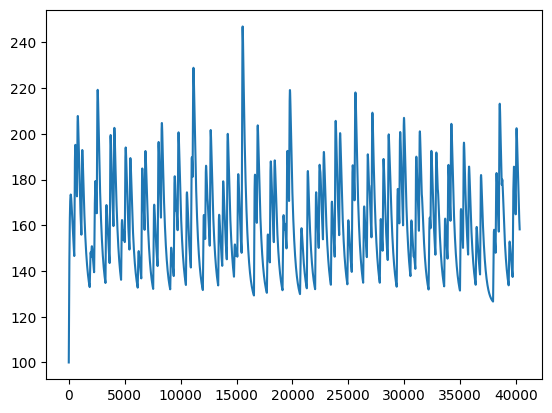

In [4]:
# continuous time integration with pre-programmed meals and insulin
# slicer = slice(0,-1)

x = MX.sym('x', 5)
U = MX.sym('u', 2)

ode = {'x':x, 'u': U, 'ode': A@x + B@U + E}
F = integrator('F','rk',ode, 0, tout ,{})

# integration only allows for one control vector U, so the u, r have to be stacked
U_seq = horzcat(u_seq, r_seq).T

# integrate
res = F(x0=[100,0,0,0,0], u=U_seq)

cgm_ruan = np.array(res['xf'][0,:].T)
fig, ax = plt.subplots()
ax.plot(tout, cgm_ruan) # np.array(df["cgm"])[slicer]

# Dataset preparation

LSTM layers require sequences as inputs.
Divide the data into input (insulin by controller, meals) and output sequences. Use some days for training, some for validation, some for testing.


In [5]:
import torch
from torch import nn
from torch.nn.utils.rnn import pack_sequence
from torch.utils.data import Dataset, DataLoader


# device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

torch.set_default_dtype(torch.float32)
torch.set_default_device("cuda")
torch.get_default_device()
torch.set_float32_matmul_precision('high')


batch_size = 32
seq_len = 50

# Two inputs: u,r
# Create packed sequences of multiple u,r
# Each sequence is obtained by sampling the dataset for 3hours. No overlap between sequences
# https://docs.pytorch.org/docs/2.12/generated/torch.nn.utils.rnn.pack_sequence.html#torch.nn.utils.rnn.pack_sequence
# https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html

class SequenceDataset(Dataset):
    def __init__(self, insulin, meals, cgm_ruan, cgm_uva, seq_length):
        assert max(insulin.shape) == max(meals.shape) == max(cgm_ruan.shape) == max(cgm_uva.shape)
        
        # add a current state reference to the data
        # in the MPC formulation, one should have the real cgm levels measured from the patient
        # or TODO: does it make more sense to use the levels computed by ruan?
        # TODO: does it make sense to pass the entire state of the ruan model? Could we have access to it in MPC?

        # prenormalize data
        # TODO: when considering boluses insulin will also need to be normalized
        # since now we're only considering basal levels, normalization would return nan
        meals_mean = meals.mean(dim=1, keepdim=True)
        meals_std = meals.std(dim=1, keepdim=True)
        cgm_uva_mean = cgm_uva.mean(dim=1, keepdim=True)
        cgm_uva_std = cgm_uva.std(dim=1, keepdim=True)

        print(cgm_uva_mean.shape, cgm_uva_mean)
        print(cgm_uva_std.shape, cgm_uva_std)

        # data = torch.cat((insulin, meals, cgm_uva), dim=0)
        data = torch.cat((insulin, meals, (cgm_uva-cgm_uva_mean)/cgm_uva_std), dim=0)

        self.len = max(data.shape)-seq_length-1
        
        # split into sequencies of length seq_length and with a stride of 1
        diff = cgm_uva - cgm_ruan
        print(diff.shape, diff)
        self.y = diff[:,:self.len].T
        
        x = []
        for i in range(self.len):
            _x = data[:,i:(i+seq_length)].T
            x.append(_x)
        
        self.x = torch.stack(x, dim=0)

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# downsample to every x minutes instead of every 1 minute
downsample_min = 5

# and cast to pytorch tensors
time_downsample = tout[::downsample_min]
insulin_t = torch.tensor(u_seq[::downsample_min], dtype=torch.float32).reshape(1, -1)
meals_t = torch.tensor(r_seq[::downsample_min], dtype=torch.float32).reshape(1, -1)
cgm_ruan_t = torch.tensor(cgm_ruan[::downsample_min], dtype=torch.float32).reshape(1, -1)
cgm_uva_t = torch.tensor(cgm_uva[::downsample_min], dtype=torch.float32).reshape(1, -1)

# Associate each sequence with its respective output
dataset = SequenceDataset(insulin_t, meals_t, cgm_ruan_t, cgm_uva_t, seq_len)
print(len(dataset))

train_percent = 0.75
val_percent = 0.15
test_percent = 0.1
train_idx = int(len(dataset) * train_percent)
val_idx = train_idx + int(len(dataset) * val_percent)
test_idx = val_idx + int(len(dataset) * test_percent)

train_dataset = torch.utils.data.Subset(dataset, range(train_idx))
val_dataset = torch.utils.data.Subset(dataset, range(train_idx, val_idx))
test_dataset = torch.utils.data.Subset(dataset, range(val_idx, test_idx))

# train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.75, 0.15, 0.10],
#                                            generator=torch.Generator(device='cuda'))

# Dataset loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size,
                                           shuffle=False)

val_loader = torch.utils.data.DataLoader(dataset=val_dataset, 
                                           batch_size=batch_size,
                                           shuffle=False)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                            batch_size = 9999999,
                                           shuffle=False)
                                           

torch.Size([1, 1]) tensor([[226.8838]], device='cuda:0')
torch.Size([1, 1]) tensor([[66.1874]], device='cuda:0')
torch.Size([1, 8065]) tensor([[22.5640, 20.2444, 17.5974,  ..., 45.1326, 40.5185, 37.1377]],
       device='cuda:0')
8014


# NN structure

The NN is made of two LSTM layers and two FC layers

In [6]:
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.callbacks.early_stopping import EarlyStoppingReason

# Lightning Module for LSTM Model
# https://lightning.ai/lightning-ai/templates/time-series-forecasting-with-pytorch-lightning?section=featured
class NN(L.LightningModule):
    def __init__(self, input_dim=3, lstm_layers=2, dropout=0.2, hidden_dim=200, output_dim=1):
        super().__init__()
        self.save_hyperparameters()
        # torch.manual_seed(2)

        # multiple LSTM layers
        # The first layer has two inputs (insulin, meal) and some hidden states

        # TODO: dropout, L2 regularization?
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=lstm_layers, dropout=dropout, batch_first=True)

        # one readout layer
        # the output is the correction to a single sampling time, so dimension 1
        self.fc1 = torch.nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        res, (h_n, c_n) = self.lstm(x.squeeze())
        res = self.fc1(res[:, -1, :])
        return res

        # _, (hidden, _) = self.lstm(x)
        # return self.fc(hidden[-1])

    def training_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self(inputs.unsqueeze(-1)).reshape((-1, 1))

        loss = torch.nn.functional.mse_loss(outputs, targets)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self(inputs.unsqueeze(-1)).reshape((-1, 1))

        loss = torch.nn.functional.mse_loss(outputs, targets)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.0002)

# hidden states size is a hyperparameter. The real dynamics of the Ruan model has five state components
# using PyTorch lightning

model = NN.load_from_checkpoint("lightning_logs/version_96/checkpoints/epoch=294-step=27730.ckpt")
model.eval()

NN(
  (lstm): LSTM(3, 200, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=200, out_features=1, bias=True)
)

In [7]:
x,y = next(iter(test_loader))
ym = model(x)
print(ym.shape, ym)

torch.Size([801, 1]) tensor([[ 3.7721e+01],
        [ 3.2283e+01],
        [ 2.7295e+01],
        [ 2.2144e+01],
        [ 1.7830e+01],
        [ 1.4369e+01],
        [ 1.1783e+01],
        [ 8.8637e+00],
        [ 6.4038e+00],
        [ 2.9243e+00],
        [ 1.7211e-01],
        [-7.8027e-01],
        [-7.1189e-01],
        [-2.4120e-01],
        [ 4.8842e-01],
        [ 1.9049e+00],
        [ 5.2048e+00],
        [ 8.6193e+00],
        [ 1.3301e+01],
        [ 1.7304e+01],
        [ 1.8011e+01],
        [ 1.6068e+01],
        [ 1.3502e+01],
        [ 1.1760e+01],
        [ 1.0574e+01],
        [ 9.4577e+00],
        [ 8.1481e+00],
        [ 6.6871e+00],
        [ 5.3138e+00],
        [ 3.1140e+00],
        [ 1.3179e+00],
        [ 1.2365e+00],
        [-1.3963e-01],
        [ 2.3208e+00],
        [ 3.2743e+00],
        [ 2.6541e+00],
        [ 2.0271e+00],
        [ 1.4380e+00],
        [ 1.4152e+00],
        [ 1.6132e+00],
        [ 1.5066e+00],
        [ 8.4672e-01],
        [-2.2

6.724408


/tmp/ipykernel_346357/1696162820.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


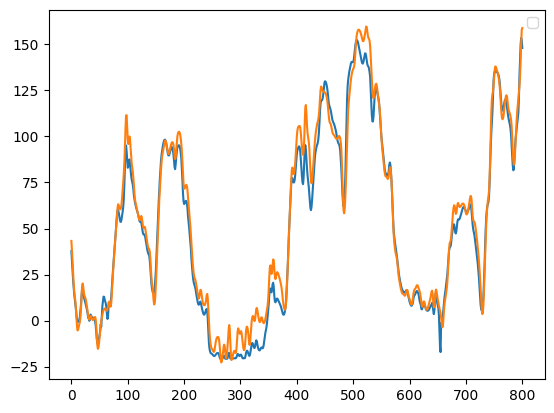

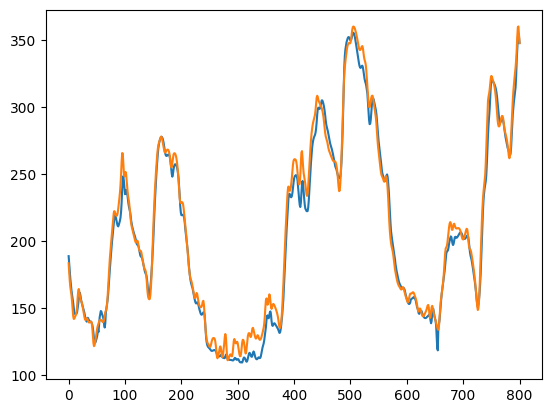

In [8]:


y_ = y.squeeze().detach().cpu().numpy()
ym_ = ym.squeeze().detach().cpu().numpy()

l = y_.shape[0]

ruan = cgm_ruan_t.squeeze()[-l-seq_len:-seq_len].cpu().numpy()
uva = cgm_uva_t.squeeze()[-l-seq_len:-seq_len].cpu().numpy()

corrected = ym_+ruan
err = uva-corrected
print(np.abs(err).mean())

# The network predicts the correct difference between ruan and UVA/Padova with very small error
fig, ax = plt.subplots()
ax.plot(ym_)
ax.plot(y_)
ax.legend()

# However there is some mismatch in time between the neural-corrected output and the real one
# but it could be just that we are taking the wrong indices (phase of -seq_len)
fig, ax = plt.subplots()
ax.plot(corrected)
ax.plot(uva)
